# WP4 period prior: analysis of the 10,000-member ensemble, Middleback-type iron body (Annex B)

The Middleback branch (WP4-B-FE) was run on Sherlock (`09_sherlock_middleback/`) for seeds 3000 to 12999 on the shared setting (`svoi_core`, Annex A v0.10), the same seeds as the sediment-hosted ensemble, so Level 1 and the barren piles are the same realizations. Each member was forward-modelled noise-free and sampled at the BMR gravity stations (1969) and the P234 magnetic readings (1962); the tests here add the survey noise where they need it. This notebook asks what the t0 surveys say about this branch's prior, with the same steps as `wp4_prior_ensemble_n10000_analysis.ipynb` for the basalt branch.

Levels 2 to 4 of this branch (ranges, belt, ore bodies) sit in the basement below the unconformity; the ranges are the one thing in it the surveys can see.

1. What the 10,000 realizations contain
2. The Section 4 gate on 10,000 members
3. The falsification screen, member by member
4. Prior falsification by robust Mahalanobis distance
5. Observed and simulated profiles
6. Which prior draws the surveys constrain
7. What the screen does to the ore question
8. Point-wise misfit and why weighting collapses
9. What this shows

Run from the `SVOI_OD` folder. Inputs: `08_prior_models/middleback/gen_n10000/` (`pred_all.npz`, `draws_all.csv`, `observed.npz`) and `09_sherlock/svoi_core.py`. Derived tables are cached beside the ensemble, keyed by a hash of its draws table, so a replaced ensemble recomputes. Figures go to `08_prior_models/middleback/figures/wp4_ENSFE_*.png`.


In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data

Loads the ensemble and the same grid, anomaly rule and observed surveys the prior notebooks use (through `svoi_core`, so the rule cannot drift). The check confirms the seeds are complete and the observed data in the ensemble folder are the ones the rule was fixed on.

In [2]:
import sys, io, contextlib, time, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import sparse, ndimage, stats

sys.path.insert(0, "09_sherlock")
with contextlib.redirect_stdout(io.StringIO()):
    import svoi_core as C
GEN = Path("08_prior_models/middleback/gen_n10000"); FIG = Path("08_prior_models/middleback/figures"); FIG.mkdir(parents=True, exist_ok=True)
DR = pd.read_csv(GEN / "draws_all.csv")
z = np.load(GEN / "pred_all.npz"); SEEDS, PRED_G = z["seeds"], z["grav"]     # magnetics (about 1 GB) is read where needed
ob = np.load(GEN / "observed.npz")
assert (DR.seed.values == SEEDS).all() and np.array_equal(SEEDS, np.arange(SEEDS.min(), SEEDS.max() + 1))
assert np.allclose(ob["grav"], C.G_OBS) and np.allclose(ob["mag"], C.M_OBS) and np.allclose(ob["grav_x"], C.GXo)
N = len(SEEDS); KEY = hashlib.sha256((GEN / "draws_all.csv").read_bytes()).hexdigest()[:10]
DRAW_COLS = [c for c in DR.columns if c[:2] in ("L1", "L2", "L3", "L4", "L5") or c[:1] == "B" and c[1:2].isdigit()]
print(f"{N:,} realizations, seeds {SEEDS.min()}-{SEEDS.max()}, none missing; draws key {KEY}")
print(f"gravity {PRED_G.shape}, magnetics ({N}, {len(C.M_OBS)}); {len(DRAW_COLS)} draw columns ({sum(c[:1] == 'L' for c in DRAW_COLS)} shared L rows, {sum(c[:1] == 'B' for c in DRAW_COLS)} B rows), {DR.shape[1]} columns in total")
print("observed surveys identical to the ones the Section 4 rule was fixed on: True")


10,000 realizations, seeds 3000-12999, none missing; draws key 08838bd281
gravity (10000, 398), magnetics (10000, 37095); 20 draw columns (13 shared L rows, 7 B rows), 31 columns in total
observed surveys identical to the ones the Section 4 rule was fixed on: True


## Step 1. What the 10,000 realizations contain

Before any data enter: the shared piles, this branch's objects and control field, and its value in the 16,905 km$^2$ window. rows B are the Middleback rows (B2-1 range intensity, B2-3 BIF density and susceptibility, B2-4 BIF fraction, B3-1 belt share, B3-2 belt length, B4-1 ore bodies per km).

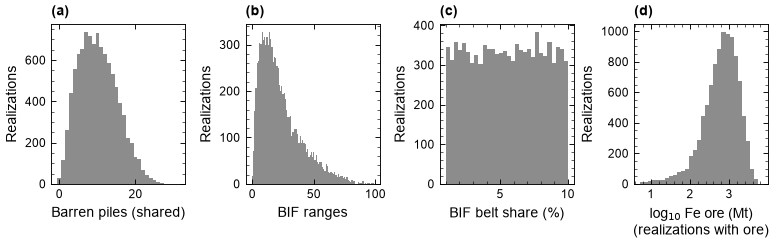

piles per realization: median 10, range 0-31 (the same realizations as the basalt ensemble)
bif ranges: median 19, range 0-98; bif belt share: median 5.5% of the window
realizations with no ore body: 1.9%; with ore: bodies median 14, Fe ore (Mt) median 709.4, 90th percentile 2,004.0 (Middleback 1952: twelve bodies of 0.05 to 59 Mt, 176 Mt in all)


In [3]:
C_PRIOR, C_KEEP, C_OBS = "#8c8c8c", "#2a78d6", "#c0504d"
fig, axes = plt.subplots(1, 4, figsize=(COL2, 2.3)); fig.subplots_adjust(left=0.07, right=0.975, top=0.88, bottom=0.25, wspace=0.45)
for ax, col, lab in [(axes[0], "n_basalt", "Barren piles (shared)"), (axes[1], "n_lens", "BIF ranges")]:
    v = DR[col].values; ax.hist(v, bins=np.arange(-0.5, v.max() + 1.5), color=C_PRIOR); ax.set_xlabel(lab); ax.set_ylabel("Realizations"); ax.xaxis.set_minor_locator(plt.NullLocator())
ax = axes[2]; ax.hist(100 * DR["belt_frac"], bins=30, color=C_PRIOR); ax.set_xlabel("BIF belt share (%)"); ax.set_ylabel("Realizations")
ax = axes[3]; m = DR["Fe_Mt_total"].values
ax.hist(np.log10(m[m > 0]), bins=30, color=C_PRIOR); ax.set_xlabel("log$_{10}$ Fe ore (Mt)\n(realizations with ore)"); ax.set_ylabel("Realizations")
panel_labels(axes, ("(a)", "(b)", "(c)", "(d)")); fig.savefig(FIG / "wp4_ENSFE_01_ensemble_contents.png", dpi=300); plt.show()
P_BARREN = (m <= 0).mean()
print(f"piles per realization: median {DR.n_basalt.median():.0f}, range {DR.n_basalt.min()}-{DR.n_basalt.max()} (the same realizations as the basalt ensemble)")
print(f"bif ranges: median {DR['n_lens'].median():.0f}, range {DR['n_lens'].min()}-{DR['n_lens'].max()}; bif belt share: median {DR['belt_frac'].median()*100:.1f}% of the window")
print(f"realizations with no ore body: {P_BARREN*100:.1f}%; with ore: bodies median {DR['n_ore'][m > 0].median():.0f}, Fe ore (Mt) median {np.median(m[m > 0]):,.1f}, 90th percentile {np.percentile(m[m > 0], 90):,.1f} (Middleback 1952: twelve bodies of 0.05 to 59 Mt, 176 Mt in all)")


**Reading the figure.** (a) Barren piles per realization, the shared Level 2. (b) This branch's objects. (c) Its control field's share of the window. (d) Its value where there is any, on a log axis. The printed lines give the medians and the share of realizations with no ore; compare the value with the analog in brackets.

## Step 2. The Section 4 gate on 10,000 members

The same five statistics per survey as the prior notebooks: remove a plane, grid to 1 km, count connected groups of at least 3 cells above 2 mGal or 20 nT, then the count per 10$^4$ km$^2$, the median and 90th-percentile peak, the median width and the residual standard deviation. One sparse matrix product per survey reproduces `anomaly_stats` exactly (checked on the first member). Cached in `wp4_ensemble_stats_n10000_<key>.csv`.

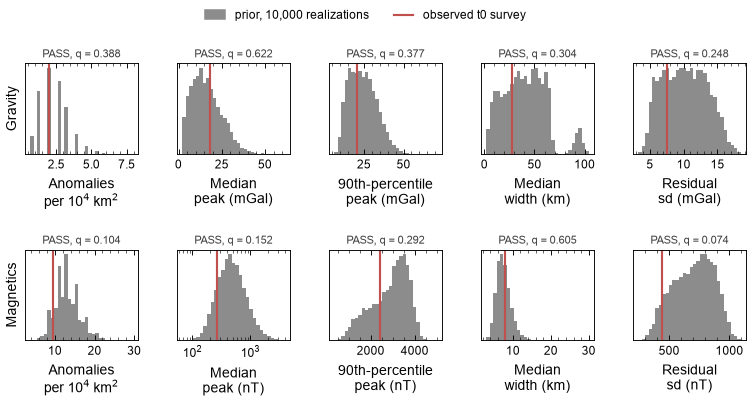

    field       statistic  observed  sim_median  quantile status  n_finite
  gravity    n_per_1e4km2     1.981       1.981     0.388   PASS     10000
  gravity      amp_median    18.059      15.206     0.622   PASS     10000
  gravity         amp_p90    20.613      23.649     0.377   PASS     10000
  gravity width_median_km    27.869      39.833     0.304   PASS     10000
  gravity     residual_sd     7.527      10.146     0.248   PASS     10000
magnetics    n_per_1e4km2     9.452      13.233     0.104   PASS     10000
magnetics      amp_median   263.288     464.986     0.152   PASS     10000
magnetics         amp_p90  2440.613    3048.968     0.292   PASS     10000
magnetics width_median_km     7.818       7.336     0.605   PASS     10000
magnetics     residual_sd   440.406     713.503     0.074   PASS     10000


In [4]:
def grid_weights(tri, GX, GY):
    P = np.c_[GX.ravel(), GY.ravel()]; s = tri.find_simplex(P); ok = s >= 0
    T = tri.transform[s[ok]]; b = np.einsum("nij,nj->ni", T[:, :2], P[ok] - T[:, 2]); bc = np.c_[b, 1 - b.sum(1)]
    W = sparse.csr_matrix((bc.ravel(), (np.repeat(np.flatnonzero(ok), 3), tri.simplices[s[ok]].ravel())), shape=(len(P), tri.npoints))
    return W, ok.reshape(GX.shape)
def plane_projector(x, y):
    A = np.c_[np.ones_like(x), (x - C.X0) / 1e3, (y - C.Y0) / 1e3]; return A, np.linalg.pinv(A)
def remove_plane(V, P):
    A, Ap = P; return V - (V @ Ap.T) @ A.T
def stats_batch(V, W, OK, P, T):
    R = remove_plane(V.astype(np.float64), P); G = np.asarray((W @ R.T).T).reshape(len(V), *OK.shape); rows = []
    for g, r in zip(G, R):
        lab, n = ndimage.label(OK & (g >= T), structure=np.ones((3, 3)))
        size = ndimage.sum(np.ones_like(g), lab, np.arange(1, n + 1)); keep = size >= C.RULE["min_cells"]
        peak = np.asarray(ndimage.maximum(np.where(OK, g, -np.inf), lab, np.arange(1, n + 1)))[keep]; width = 2 * np.sqrt(size[keep] / np.pi)
        rows.append(dict(n_per_1e4km2=keep.sum() / OK.sum() * 1e4, amp_median=np.median(peak) if len(peak) else np.nan, amp_p90=np.percentile(peak, 90) if len(peak) else np.nan,
                         width_median_km=np.median(width) if len(width) else np.nan, residual_sd=r.std()))
    return rows
WG, OKG = grid_weights(C.TRI_G, C.GX, C.GY); PG_ = plane_projector(C.GXo, C.GYo)
WM, OKM = grid_weights(C.TRI_M, C.GX, C.GY); PM_ = plane_projector(C.MXo, C.MYo)
ref = C.anomaly_stats(C.TRI_G, C.GXo, C.GYo, PRED_G[0].astype(float), C.RULE["T_grav_mgal"])[0]; new = stats_batch(PRED_G[:1], WG, OKG, PG_, C.RULE["T_grav_mgal"])[0]
assert all(np.isclose(ref[k], new[k], equal_nan=True) for k in ref)
CACHE = GEN / f"wp4_ensemble_stats_n10000_{KEY}.csv"
if CACHE.exists():
    ST = pd.read_csv(CACHE)
else:
    t0 = time.time(); sg = stats_batch(PRED_G, WG, OKG, PG_, C.RULE["T_grav_mgal"])
    PRED_M = np.load(GEN / "pred_all.npz")["mag"]; sm = []
    for i in range(0, N, 500): sm += stats_batch(PRED_M[i:i + 500], WM, OKM, PM_, C.RULE["T_mag_nt"])
    del PRED_M
    ST = pd.concat([pd.DataFrame({"seed": SEEDS}), pd.DataFrame(sg).add_prefix("g_"), pd.DataFrame(sm).add_prefix("m_")], axis=1); ST.to_csv(CACHE, index=False)
    print(f"statistics computed in {time.time() - t0:.0f} s")
OBS = {"g": C.OBS_G, "m": C.OBS_M}
STATS = [("n_per_1e4km2", "Anomalies\nper 10$^4$ km$^2$", False), ("amp_median", "Median\npeak", True), ("amp_p90", "90th-percentile\npeak", True), ("width_median_km", "Median\nwidth (km)", False), ("residual_sd", "Residual\nsd", True)]
UNIT = {"g": "mGal", "m": "nT"}
def gate(sim, obs):
    sim = np.asarray(sim, float); sim = sim[np.isfinite(sim)]; tie = np.isclose(sim, obs, rtol=1e-9, atol=0)
    q = (sim < obs)[~tie].sum() / len(sim) + 0.5 * tie.mean()
    return q, "PASS" if 0.05 <= q <= 0.95 else ("WARN" if sim.min() <= obs <= sim.max() else "FAIL")
fig, axes = plt.subplots(2, 5, figsize=(COL2, 3.6)); fig.subplots_adjust(left=0.07, right=0.98, top=0.86, bottom=0.16, wspace=0.35, hspace=1.05)
GATE = []
for r, f in enumerate(("g", "m")):
    for c, (key, lab, unit) in enumerate(STATS):
        ax = axes[r, c]; sim = ST[f"{f}_{key}"].dropna().values; o = OBS[f][key]
        allv = np.r_[sim, o]; logx = unit and allv.min() > 0 and allv.max() / allv.min() > 30
        ax.hist(sim, bins=np.geomspace(allv.min() * 0.9, allv.max() * 1.1, 30) if logx else 30, color=C_PRIOR)
        if logx: ax.set_xscale("log")
        ax.axvline(o, color=C_OBS, lw=1.4); q, st = gate(sim, o)
        GATE.append(dict(field={"g": "gravity", "m": "magnetics"}[f], statistic=key, observed=o, sim_median=np.median(sim), quantile=q, status=st, n_finite=len(sim)))
        ax.text(0.5, 1.04, f"{st}, q = {q:.3f}", transform=ax.transAxes, ha="center", va="bottom", fontsize=FS_ANNOT, color="0.25")
        ax.set_xlabel(lab + (f" ({UNIT[f]})" if unit else "")); ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator())
axes[0, 0].set_ylabel("Gravity"); axes[1, 0].set_ylabel("Magnetics")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C_PRIOR, label=f"prior, {N:,} realizations"), plt.Line2D([], [], color=C_OBS, lw=1.4, label="observed t0 survey")], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.savefig(FIG / "wp4_ENSFE_02_gate_n10000.png", dpi=300); plt.show()
GATE = pd.DataFrame(GATE); GATE.to_csv(GEN / "wp4_ensemble_gate_n10000.csv", index=False); print(GATE.round(3).to_string(index=False))


**Reading the figure.** Grey histograms are the statistic over the 10,000 members, the red line the observed survey, and the text above each panel the gate status with $q$, the share of members below the observed value. Compare with the 200-member gate of the branch's prior notebook and with the basalt ensemble's gate: the statistics that depend on the shared setting should agree across branches; the ones this branch's objects move are where the verdicts can differ.

## Step 3. The falsification screen, member by member

A realization is **not falsified** when its anomaly populations are indistinguishable from the surveys by the ten Step 2 statistics: $z_j = (s_j - s_j^{obs}) / \mathrm{MAD}_j$ (logs for the peak, width and sd statistics, MAD the scaled median absolute deviation over the members), and a member survives if every $|z_j| < \epsilon$ with $\epsilon$ = 2 fixed before the result is looked at. `falsify()` is the one function to replace with another algorithm; everything downstream uses only its boolean.

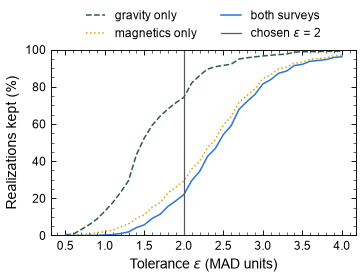

survivors at eps = 2: 2,194 of 10,000 (21.9%); written to wp4_ensemble_survivors.csv
kept at eps = 1.5 / 2 / 3: 5.7% / 21.9% / 81.5%
gravity alone keeps 74.3%, magnetics alone 29.3%
statistic with the largest |z| among the rejected:
m_residual_sd        2973
m_n_per_1e4km2       1952
m_amp_median          827
m_amp_p90             515
g_width_median_km     468


In [5]:
LOGSTAT = {"amp_median", "amp_p90", "width_median_km", "residual_sd"}
EPS = 2.0
def zscores(ST):
    Z = {}
    for f in ("g", "m"):
        for key, _, _ in STATS:
            s, o = ST[f"{f}_{key}"].values.astype(float), OBS[f][key]
            if key in LOGSTAT: s, o = np.log(s), np.log(o)
            mad = 1.4826 * np.nanmedian(np.abs(s - np.nanmedian(s))); Z[f"{f}_{key}"] = np.where(np.isfinite(s), (s - o) / mad, np.inf)
    return pd.DataFrame(Z)
def falsify(ST, eps=EPS):
    """True = survives"""
    return (zscores(ST).abs() < eps).all(axis=1).values
Z = zscores(ST); KEEP = falsify(ST)
eps_grid = np.linspace(0.5, 4, 36)
acc = {lab: [(Z[cols].abs() < e).all(axis=1).mean() for e in eps_grid] for lab, cols in [("gravity only", [c for c in Z if c[0] == "g"]), ("magnetics only", [c for c in Z if c[0] == "m"]), ("both surveys", list(Z))]}
fig, ax = plt.subplots(figsize=(COL1, 2.6)); fig.subplots_adjust(left=0.18, right=0.97, top=0.82, bottom=0.17)
for (lab, a), col, ls in zip(acc.items(), ("#2e5e4e", "#eda100", C_KEEP), ("--", ":", "-")): ax.plot(eps_grid, np.array(a) * 100, color=col, ls=ls, label=lab)
ax.axvline(EPS, color="0.35", lw=0.8, label=f"chosen $\\epsilon$ = {EPS:g}"); ax.set_xlabel("Tolerance $\\epsilon$ (MAD units)"); ax.set_ylabel("Realizations kept (%)"); ax.set_ylim(0, 100)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2); fig.savefig(FIG / "wp4_ENSFE_03_screen_acceptance.png", dpi=300); plt.show()
SURV = DR[KEEP].copy(); SURV.to_csv(GEN / "wp4_ensemble_survivors.csv", index=False)
worst = Z.abs().idxmax(axis=1)[~KEEP].value_counts()
print(f"survivors at eps = {EPS:g}: {KEEP.sum():,} of {N:,} ({KEEP.mean()*100:.1f}%); written to wp4_ensemble_survivors.csv")
print("kept at eps = 1.5 / 2 / 3: " + " / ".join(f"{(Z.abs() < e).all(axis=1).mean()*100:.1f}%" for e in (1.5, 2, 3)))
print(f"gravity alone keeps {acc['gravity only'][np.argmin(abs(eps_grid - EPS))]*100:.1f}%, magnetics alone {acc['magnetics only'][np.argmin(abs(eps_grid - EPS))]*100:.1f}%")
print("statistic with the largest |z| among the rejected:"); print(worst.head(5).to_string())


**Reading the figure.** Each curve is the share of members kept as the tolerance widens, for each survey alone and for both; the vertical line is the chosen $\epsilon$ = 2. The printed lines give the survivors and the statistic that most often rejects a member.

## Step 4. Prior falsification by robust Mahalanobis distance

The test of the prior as a whole on the data themselves (after D. Yin, Stanford, 2019): plane removed from members and survey, each data point scaled to [-1, 1] over members and survey, projection on the first 20 principal components (randomized PCA), a robust location and covariance (minimum covariance determinant), and the robust Mahalanobis distance of each member and of the survey; falsified if the survey's distance exceeds the 95th percentile of the members'. The share of the survey's variance inside the components is reported with the distance. Cached in `wp4_ensemble_rmd_<key>.npz`.

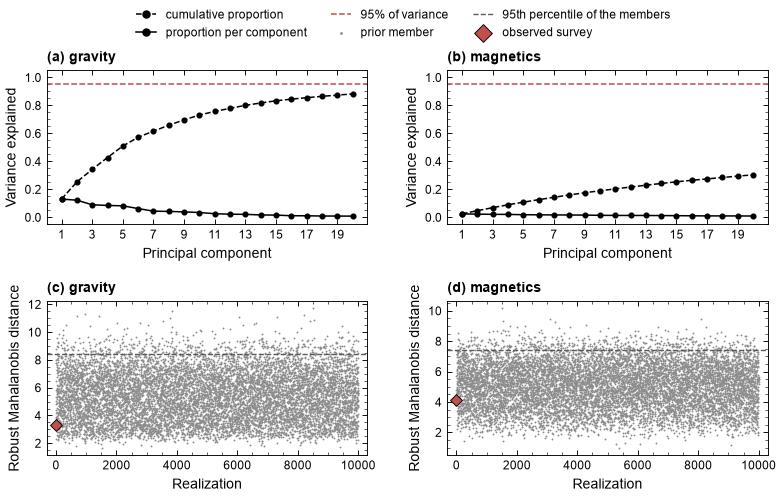

           survey  rmd_obs  rmd_q95  obs_percentile  falsified  var_in_pcs  obs_share_in_pcs  members_share_median  obs_share_percentile
          gravity    3.346    8.397           14.31      False       0.882             0.742                 0.884                  1.22
        magnetics    4.120    7.403           28.67      False       0.304             0.499                 0.295                 99.03
joint (40 scores)    4.783    9.513            7.72      False         NaN               NaN                   NaN                   NaN


In [7]:
from sklearn.decomposition import PCA
from sklearn.covariance import MinCovDet
N_PCS, Q_RMD = 20, 95
def rmd_falsification(V, obs, P, n_pcs=N_PCS, q=Q_RMD):
    A, Ap = (m.astype(np.float32) for m in P)
    for i in range(0, len(V), 500): V[i:i + 500] -= (V[i:i + 500] @ Ap.T) @ A.T
    o = (obs - (obs @ Ap.T) @ A.T).astype(np.float32)[None, :]
    lo = np.minimum(V.min(0), o[0]); sc = 2 / (np.maximum(V.max(0), o[0]) - lo)
    for i in range(0, len(V), 500): V[i:i + 500] = (V[i:i + 500] - lo) * sc - 1
    o = (o - lo) * sc - 1
    pca = PCA(n_components=n_pcs, svd_solver="randomized", random_state=0).fit(V); X, Xo = pca.transform(V), pca.transform(o)
    mcd = MinCovDet(random_state=0).fit(X); Pinv = np.linalg.inv(mcd.covariance_)
    md = np.sqrt(np.einsum("ij,jk,ik->i", X - mcd.location_, Pinv, X - mcd.location_)); md_obs = float(np.sqrt((Xo - mcd.location_) @ Pinv @ (Xo - mcd.location_).T).item())
    tot = np.concatenate([((V[i:i + 500] - pca.mean_) ** 2).sum(1) for i in range(0, len(V), 500)]); tot_o = float(((o - pca.mean_) ** 2).sum())
    return dict(evr=pca.explained_variance_ratio_, X=X, Xo=Xo, md=md, md_obs=md_obs, q_md=float(np.percentile(md, q)), pct_obs=float((md < md_obs).mean()), cap=(X ** 2).sum(1) / tot, cap_obs=float((Xo ** 2).sum() / tot_o))
CACHE_R = GEN / f"wp4_ensemble_rmd_{KEY}.npz"
if CACHE_R.exists():
    zr = np.load(CACHE_R, allow_pickle=True); RES = zr["RES"].item()
else:
    t0 = time.time(); RES = {"g": rmd_falsification(PRED_G.astype(np.float32), C.G_OBS, PG_)}
    PRED_M = np.load(GEN / "pred_all.npz")["mag"]; RES["m"] = rmd_falsification(PRED_M, C.M_OBS, PM_); del PRED_M
    XJ = np.c_[RES["g"]["X"], RES["m"]["X"]]; XJo = np.c_[RES["g"]["Xo"], RES["m"]["Xo"]]
    mcdJ = MinCovDet(random_state=0).fit(XJ); PJ = np.linalg.inv(mcdJ.covariance_)
    mdJ = np.sqrt(np.einsum("ij,jk,ik->i", XJ - mcdJ.location_, PJ, XJ - mcdJ.location_)); mdJo = float(np.sqrt((XJo - mcdJ.location_) @ PJ @ (XJo - mcdJ.location_).T).item())
    RES["j"] = dict(md=mdJ, md_obs=mdJo, q_md=float(np.percentile(mdJ, Q_RMD)), pct_obs=float((mdJ < mdJo).mean()))
    np.savez_compressed(CACHE_R, RES=np.array(RES, dtype=object)); print(f"distances computed in {time.time() - t0:.0f} s")
fig, axes = plt.subplots(2, 2, figsize=(COL2, 4.6)); fig.subplots_adjust(left=0.08, right=0.99, top=0.87, bottom=0.11, wspace=0.25, hspace=0.5)
k = np.arange(1, N_PCS + 1)
for c, f in enumerate(("g", "m")):
    r = RES[f]; ax = axes[0, c]
    ax.plot(k, r["evr"].cumsum(), "o--", color="k", ms=3, label="cumulative proportion"); ax.plot(k, r["evr"], "o-", color="k", ms=3, label="proportion per component")
    ax.axhline(0.95, color=C_OBS, ls="--", lw=1.0, label="95% of variance"); ax.set_xticks(k[::2]); ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Principal component"); ax.set_ylabel("Variance explained")
    ax = axes[1, c]
    ax.scatter(np.arange(1, N + 1), r["md"], s=1.5, color=C_PRIOR, lw=0, rasterized=True, label="prior member")
    ax.axhline(r["q_md"], color="0.35", ls="--", lw=0.9, label=f"{Q_RMD}th percentile of the members")
    ax.scatter([0], [r["md_obs"]], marker="D", s=30, color=C_OBS, edgecolor="k", lw=0.6, zorder=5, label="observed survey")
    ax.set_xlim(-0.03 * N, 1.03 * N); ax.set_xlabel("Realization"); ax.set_ylabel("Robust Mahalanobis distance")
h1, l1 = axes[0, 0].get_legend_handles_labels(); h2, l2 = axes[1, 0].get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc="upper center", ncol=3, bbox_to_anchor=(0.53, 1.01), markerscale=1.5)
panel_labels(axes.ravel(), ("(a) gravity", "(b) magnetics", "(c) gravity", "(d) magnetics")); fig.savefig(FIG / "wp4_ENSFE_04_rmd_falsification.png", dpi=300); plt.show()
RMD_TAB = pd.DataFrame([dict(survey=n, rmd_obs=RES[f]["md_obs"], rmd_q95=RES[f]["q_md"], obs_percentile=RES[f]["pct_obs"] * 100, falsified=RES[f]["md_obs"] > RES[f]["q_md"],
                             var_in_pcs=RES[f]["evr"].sum() if f != "j" else np.nan, obs_share_in_pcs=RES[f].get("cap_obs", np.nan),
                             members_share_median=np.median(RES[f]["cap"]) if f != "j" else np.nan, obs_share_percentile=(RES[f]["cap"] < RES[f]["cap_obs"]).mean() * 100 if f != "j" else np.nan)
                        for n, f in [("gravity", "g"), ("magnetics", "m"), ("joint (40 scores)", "j")]])
RMD_TAB.to_csv(GEN / "wp4_ensemble_rmd_falsification.csv", index=False); print(RMD_TAB.round(3).to_string(index=False))


**Reading the figure.** (a, b) Share of the members' variance in each of the first 20 principal components (solid) and cumulatively (dashed); the red dashed line is 95%. (c, d) Robust Mahalanobis distance of each member (grey), their 95th percentile (dashed) and the survey (red diamond at realization 0). The printed table gives the verdicts, the share of variance the components carry, and the survey's own share of energy inside them against the members'.

## Step 5. Observed and simulated profiles

West-east profile at the Olympic Dam northing: the plane-removed residual of all 10,000 members, gridded by the Step 2 rule, against the observed one.

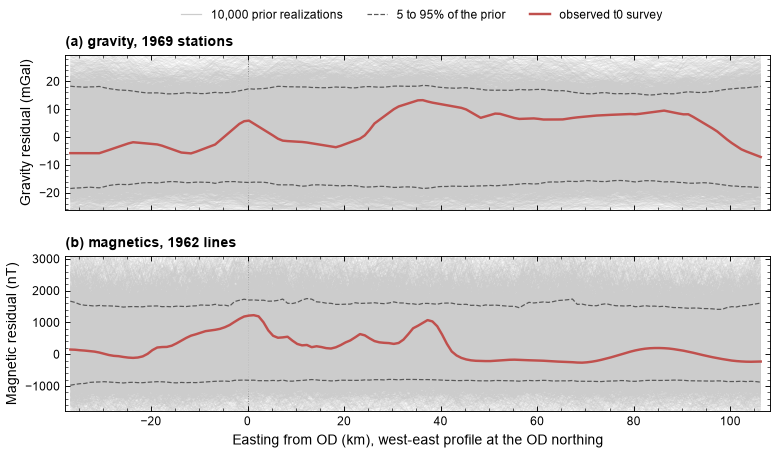

gravity: observed -7.2 to 13.2; inside the 5-95% band at 100% of points; envelope -19 to 19; at the OD easting 5.9, above 72% of members
magnetics: observed -266.0 to 1226.6; inside the 5-95% band at 100% of points; envelope -976 to 1750; at the OD easting 1214.0, above 92% of members


In [ ]:
import warnings; warnings.filterwarnings("ignore", message="All-NaN slice")
iy = int(np.argmin(abs(C.YC - C.ODY))); xkm = (C.XC - C.ODX) / 1e3; rows = slice(iy * C.NX, (iy + 1) * C.NX)
PROF_G = np.asarray((WG[rows] @ remove_plane(PRED_G.astype(np.float64), PG_).T).T)
PRED_M = np.load(GEN / "pred_all.npz")["mag"]
PROF_M = np.vstack([np.asarray((WM[rows] @ remove_plane(PRED_M[i:i + 500].astype(np.float64), PM_).T).T) for i in range(0, N, 500)]); del PRED_M
PROF_G[:, ~OKG[iy]] = np.nan; PROF_M[:, ~OKM[iy]] = np.nan
OBS_PROF = {"g": np.where(OKG[iy], C.GRID_G[iy], np.nan), "m": np.where(OKM[iy], C.GRID_M[iy], np.nan)}
from matplotlib.collections import LineCollection
fig, axes = plt.subplots(2, 1, figsize=(COL2, 4.2), sharex=True); fig.subplots_adjust(left=0.1, right=0.99, top=0.88, bottom=0.11, hspace=0.3)
PROF_SUM = []
for ax, prof, f, lab in [(axes[0], PROF_G, "g", "Gravity residual (mGal)"), (axes[1], PROF_M, "m", "Magnetic residual (nT)")]:
    ax.add_collection(LineCollection([np.c_[xkm, v] for v in prof], colors="0.8", linewidths=0.25, alpha=0.25, zorder=1, rasterized=True))
    lo, hi = np.nanpercentile(prof, [5, 95], axis=0); ax.plot(xkm, lo, color="0.35", lw=0.8, ls="--", zorder=2); ax.plot(xkm, hi, color="0.35", lw=0.8, ls="--", zorder=2)
    obs = OBS_PROF[f]; ax.plot(xkm, obs, color=C_OBS, lw=1.6, zorder=4); ax.axvline(0, color="k", lw=0.6, ls=":", zorder=0); ax.set_ylabel(lab); ax.set_xlim(xkm[0], xkm[-1])
    ok = np.isfinite(obs); ax.set_ylim(np.nanpercentile(np.r_[prof[:, ok].ravel(), obs[ok]], 0.5), np.nanpercentile(np.r_[prof[:, ok].ravel(), obs[ok]], 99.5))
    PROF_SUM.append(dict(field={"g": "gravity", "m": "magnetics"}[f], obs_min=np.nanmin(obs), obs_max=np.nanmax(obs), inside_all=((obs[ok] >= lo[ok]) & (obs[ok] <= hi[ok])).mean(),
                         env_all=f"{np.nanmin(lo[ok]):.0f} to {np.nanmax(hi[ok]):.0f}", obs_at_OD=obs[np.argmin(abs(xkm))], obs_q_at_OD=(prof[:, np.argmin(abs(xkm))] < obs[np.argmin(abs(xkm))]).mean()))
axes[1].set_xlabel("Easting from OD (km), west-east profile at the OD northing"); panel_labels(axes, ("(a) gravity, 1969 stations", "(b) magnetics, 1962 lines"))
fig.legend(handles=[plt.Line2D([], [], color="0.8", lw=0.8, label=f"{N:,} prior realizations"), plt.Line2D([], [], color="0.35", lw=0.8, ls="--", label="5 to 95% of the prior"), plt.Line2D([], [], color=C_OBS, lw=1.6, label="observed t0 survey")], loc="upper center", ncol=3, bbox_to_anchor=(0.55, 1.0))
fig.savefig(FIG / "wp4_ENSFE_05_profiles_observed_vs_prior.png", dpi=300); plt.show()
for _, r in pd.DataFrame(PROF_SUM).iterrows():
    print(f"{r.field}: observed {r.obs_min:.1f} to {r.obs_max:.1f}; inside the 5-95% band at {r.inside_all*100:.0f}% of points; envelope {r.env_all}; at the OD easting {r.obs_at_OD:.1f}, above {r.obs_q_at_OD*100:.0f}% of members")


**Reading the figure.** Grey lines are all 10,000 realizations, dashed their 5 to 95% envelope, red the survey, dotted the OD easting. The printed lines say how much of the observed profile the envelope holds and where the survey sits at the Olympic Dam easting.

## Step 6. Which prior draws the surveys constrain

For each realization-level draw, the Kolmogorov-Smirnov distance between its distribution in all members and in the survivors of Step 3: 0 means the surveys say nothing about that draw. Shared L rows and this branch's rows are shown together, coloured by level.

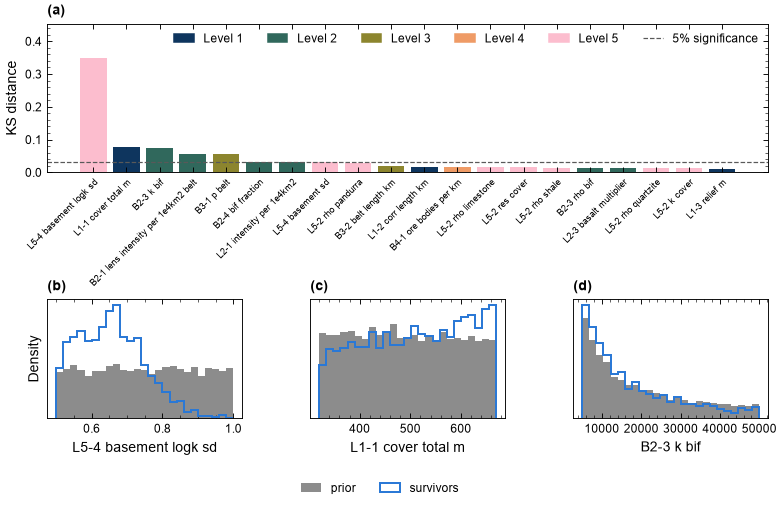

5% critical KS distance for 10,000 against 2,194: 0.032; draws above it: 6
                               draw    ks  prior_median  survivor_median
              L5-4 basement_logk_sd 0.349         0.749            0.653
                 L1-1 cover_total_m 0.077       490.229          514.355
                         B2-3 k_bif 0.076     15626.509        13621.718
B2-1 lens_intensity_per_1e4km2_belt 0.057       224.610          205.497
                        B3-1 p_belt 0.055         0.055            0.051
                  B2-4 bif_fraction 0.032         0.494            0.481
          L2-1 intensity_per_1e4km2 0.031         5.957            5.887
                   L5-4 basement_sd 0.031         0.065            0.064
                  L5-2 rho_pandurra 0.030         2.439            2.441
                B3-2 belt_length_km 0.019        34.554           34.623
                L1-2 corr_length_km 0.018        22.482           22.614
             B4-1 ore_bodies_per_km 0.017        

In [ ]:
KS = pd.DataFrame([dict(draw=c, ks=stats.ks_2samp(DR[c], SURV[c]).statistic, prior_median=DR[c].median(), survivor_median=SURV[c].median()) for c in DRAW_COLS]).sort_values("ks", ascending=False).reset_index(drop=True)
LEVEL_COL = {k: BATLOW(v) for k, v in zip(range(1, 6), (0.08, 0.30, 0.52, 0.74, 0.92))}
fig = plt.figure(figsize=(COL2, 4.6)); gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1], hspace=0.95, wspace=0.35, left=0.08, right=0.99, top=0.95, bottom=0.17)
ax = fig.add_subplot(gs[0, :]); ax.bar(np.arange(len(KS)), KS.ks, color=[LEVEL_COL[int(d[1])] for d in KS.draw])
ax.set_xticks(np.arange(len(KS))); ax.set_xticklabels([d.replace("_", " ") for d in KS.draw], rotation=45, ha="right", rotation_mode="anchor", fontsize=FS_ANNOT - 1); ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylabel("KS distance")
KS_CRIT = 1.358 * np.sqrt(1 / N + 1 / max(KEEP.sum(), 1)); ax.axhline(KS_CRIT, color="0.35", lw=0.8, ls="--")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, label=f"Level {k}") for k, c in LEVEL_COL.items()] + [plt.Line2D([], [], color="0.35", lw=0.8, ls="--", label="5% significance")], ncol=6, loc="upper right"); ax.set_ylim(0, KS.ks.max() * 1.3)
sub = [fig.add_subplot(gs[1, j]) for j in range(3)]
for a, d in zip(sub, KS.draw[:3]):
    bins = np.histogram_bin_edges(DR[d], 25); a.hist(DR[d], bins=bins, density=True, color=C_PRIOR, label="prior"); a.hist(SURV[d], bins=bins, density=True, histtype="step", color=C_KEEP, lw=1.3, label="survivors")
    a.set_xlabel(d.replace("_", " ")); a.set_yticks([]); a.yaxis.set_minor_locator(plt.NullLocator())
sub[0].set_ylabel("Density"); fig.legend(*sub[0].get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=2)
panel_labels([ax] + sub, ("(a)", "(b)", "(c)", "(d)")); fig.savefig(FIG / "wp4_ENSFE_06_constrained_draws.png", dpi=300); plt.show()
KS.to_csv(GEN / "wp4_ensemble_ks_draws.csv", index=False)
print(f"5% critical KS distance for {N:,} against {KEEP.sum():,}: {KS_CRIT:.3f}; draws above it: {int((KS.ks > KS_CRIT).sum())}"); print(KS.round(3).to_string(index=False))


**Reading the figure.** (a) KS distance per draw, coloured by level, the dashed line the 5% significance level. (b) to (d) Prior (grey) and survivors (blue outline) for the three most constrained draws. Draws above the line are the ones the surveys move; in the basalt ensemble these were the regional background rows (basement spreads, cover thickness). Any of this branch's own rows above the line is a row the surveys see through its objects.

## Step 7. What the screen does to the ore question

The branch's value is not an anomaly source in itself, so the surveys reach it only through the geology it needs. This step compares the ore summaries before and after the screen. (Middleback 1952: twelve bodies of 0.05 to 59 Mt, 176 Mt in all.)

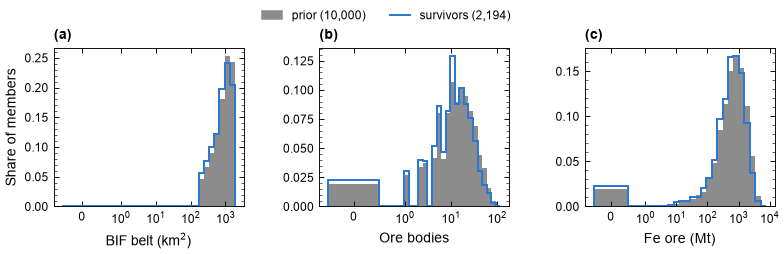

prior    : no ore in the window   1.9% (95% CI 1.7-2.2); median bif belt    932; median bodies   13; median Fe ore (Mt)    691.5
survivors: no ore in the window   2.2% (95% CI 1.7-2.9); median bif belt    866; median bodies   12; median Fe ore (Mt)    604.9


In [ ]:
def boot_ci(x, f=np.mean, B=2000, seed=0):
    r = np.random.default_rng(seed); x = np.asarray(x); v = [f(x[r.integers(0, len(x), len(x))]) for _ in range(B)]; return np.percentile(v, [2.5, 97.5])
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.4)); fig.subplots_adjust(left=0.08, right=0.99, top=0.84, bottom=0.24, wspace=0.4)
for ax, col, lab in [(axes[0], "belt_km2", "BIF belt (km$^2$)"), (axes[1], "n_ore", "Ore bodies"), (axes[2], "Fe_Mt_total", "Fe ore (Mt)")]:
    a, b = DR[col].values, SURV[col].values; bins = np.r_[-0.5, np.geomspace(0.5, max(a.max(), 1) * 1.1, 25)]
    ax.hist(a, bins=bins, weights=np.full(len(a), 1 / len(a)), color=C_PRIOR); ax.hist(b, bins=bins, weights=np.full(len(b), 1 / max(len(b), 1)), histtype="step", color=C_KEEP, lw=1.3)
    ax.set_xscale("symlog", linthresh=1); ax.set_xlabel(lab)
axes[0].set_ylabel("Share of members")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C_PRIOR, label=f"prior ({N:,})"), plt.Line2D([], [], color=C_KEEP, lw=1.3, label=f"survivors ({KEEP.sum():,})")], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
panel_labels(axes, ("(a)", "(b)", "(c)")); fig.savefig(FIG / "wp4_ENSFE_07_ore_before_after.png", dpi=300); plt.show()
for lab, d in [("prior", DR), ("survivors", SURV)]:
    if len(d) == 0: print(f"{lab}: none"); continue
    ci = boot_ci((d["Fe_Mt_total"] <= 0).values)
    print(f"{lab:9s}: no ore in the window {(d['Fe_Mt_total'] <= 0).mean()*100:5.1f}% (95% CI {ci[0]*100:.1f}-{ci[1]*100:.1f}); median bif belt {d['belt_km2'].median():6.0f}; median bodies {d['n_ore'].median():4.0f}; median Fe ore (Mt) {d['Fe_Mt_total'].median():8,.1f}")


**Reading the figure.** Bars are the share of members per bin, grey the prior, blue outline the survivors; the axes are linear up to 1 and logarithmic above, so the first bar is the members with no zone, no body or no ore. If the survivors match the prior, the surveys leave the ore question where the prior put it; a shift says the screen reaches the ore through the objects it can see.

## Step 8. Point-wise misfit and why weighting collapses

The alternative to screening is likelihood weighting: the normalized misfit per survey is $\chi^2/n$ after a plane is removed, and tempering the Gaussian likelihood by $\tau$ shows how much model error would have to be admitted before the weights spread over more than a handful of members; $\mathrm{ESS} = 1/\sum w^2$.

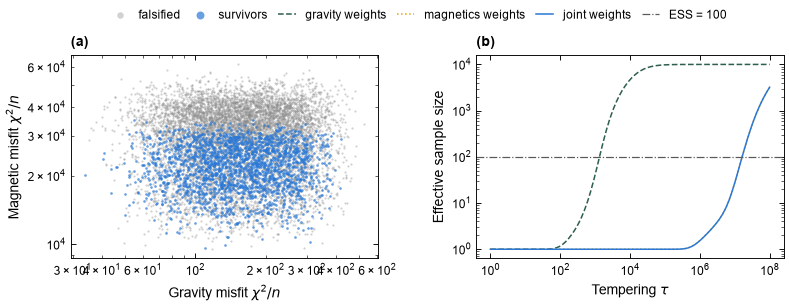

best normalized misfit: gravity 33.8 (median 154.4); magnetics 9519 (median 28011)
ESS at tau = 1: gravity 1.00, magnetics 1.00, joint 1.00
tau needed for ESS >= 100: gravity 1,400, magnetics 19,094,086, joint 19,094,086
Spearman correlation, survivor flag vs gravity misfit -0.01, vs magnetic misfit -0.35


In [ ]:
PRED_M = np.load(GEN / "pred_all.npz")["mag"]
def chi2(V, obs, sd, P, B=500):
    out = np.empty(len(V))
    for i in range(0, len(V), B):
        D = remove_plane(obs[None, :] - V[i:i + B].astype(np.float64), P); out[i:i + B] = ((D / sd) ** 2).sum(1)
    return out
CHI_G = chi2(PRED_G, C.G_OBS, C.G_SD, PG_); CHI_M = chi2(PRED_M, C.M_OBS, C.RULE["mag_noise_nt"], PM_); del PRED_M
nG, nM = len(C.G_OBS), len(C.M_OBS)
def ess(chi, tau):
    lw = -chi / (2 * tau); w = np.exp(lw - lw.max()); w /= w.sum(); return 1 / (w ** 2).sum()
taus = np.geomspace(1, 1e8, 90); E = {lab: np.array([ess(ch, t) for t in taus]) for lab, ch in [("gravity", CHI_G), ("magnetics", CHI_M), ("joint", CHI_G + CHI_M)]}
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8)); fig.subplots_adjust(left=0.09, right=0.99, top=0.84, bottom=0.18, wspace=0.32)
ax = axes[0]; ax.scatter(CHI_G[~KEEP] / nG, CHI_M[~KEEP] / nM, s=2, color=C_PRIOR, alpha=0.4, lw=0, label="falsified"); ax.scatter(CHI_G[KEEP] / nG, CHI_M[KEEP] / nM, s=3, color=C_KEEP, alpha=0.7, lw=0, label="survivors")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("Gravity misfit $\\chi^2/n$"); ax.set_ylabel("Magnetic misfit $\\chi^2/n$")
ax = axes[1]
for (lab, e), col, ls in zip(E.items(), ("#2e5e4e", "#eda100", C_KEEP), ("--", ":", "-")): ax.plot(taus, e, color=col, ls=ls, label=f"{lab} weights")
ax.axhline(100, color="0.35", lw=0.8, ls="-.", label="ESS = 100"); ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("Tempering $\\tau$"); ax.set_ylabel("Effective sample size")
h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = axes[1].get_legend_handles_labels(); fig.legend(h1 + h2, l1 + l2, loc="upper center", ncol=6, bbox_to_anchor=(0.53, 1.02), markerscale=3, handlelength=1.4, columnspacing=0.9)
panel_labels(axes, ("(a)", "(b)")); fig.savefig(FIG / "wp4_ENSFE_08_misfit_and_ess.png", dpi=300); plt.show()
need = {lab: taus[np.argmax(e >= 100)] if (e >= 100).any() else np.nan for lab, e in E.items()}
print(f"best normalized misfit: gravity {CHI_G.min()/nG:.1f} (median {np.median(CHI_G)/nG:.1f}); magnetics {CHI_M.min()/nM:.0f} (median {np.median(CHI_M)/nM:.0f})")
print(f"ESS at tau = 1: gravity {E['gravity'][0]:.2f}, magnetics {E['magnetics'][0]:.2f}, joint {E['joint'][0]:.2f}"); print("tau needed for ESS >= 100: " + ", ".join(f"{k} {v:,.0f}" for k, v in need.items()))
print(f"Spearman correlation, survivor flag vs gravity misfit {stats.spearmanr(KEEP, CHI_G)[0]:+.2f}, vs magnetic misfit {stats.spearmanr(KEEP, CHI_M)[0]:+.2f}")


**Reading the figure.** (a) Each dot is one member, normalized misfit to the gravity stations against the magnetic readings after a plane is removed; blue are the Step 3 survivors. (b) Effective sample size of the likelihood weights as the likelihood is tempered. At $\tau$ = 1 the ESS should be about 1 for each survey, as in the basalt ensemble: point-wise weighting collapses onto one member, which is why the screen and the distance test are the workable routes.

## What this shows

1. Fill in from the printed outputs after the run: the gate verdicts (Step 2), the survivor share (Step 3), the falsification verdicts (Step 4), the profile envelope (Step 5), the constrained draws (Step 6), the ore question before and after the screen (Step 7), and the ESS (Step 8).
2. Read beside the basalt ensemble's analysis: the shared statistics should agree; the differences are this branch's objects at work.

Next: the same analysis for the remaining branch, then the district comparison of the branches (Bayes factors on window statistics, paired by seed) and the drilling likelihood.